In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymysql
from sqlalchemy import create_engine

#### Configuración de Conexión a MySQL

In [12]:
from sqlalchemy import create_engine

USER = 'root'
PASSWORD = 'copado321'
HOST = 'localhost'
PORT = '3306'
DB_NAME = 'enigh_db'


In [13]:
connection_string = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}"
engine = create_engine(connection_string)

#### Cálculo del Coeficiente de Gini Ponderado

In [14]:


def weighted_gini(income, weights):
    """
    Calcula el Coeficiente de Gini considerando los factores de expansión (pesos).
    Retorna: gini, p (proporción acumulada de población), l (proporción acumulada de ingreso).
    """
    # Construir DataFrame y eliminar nulos
    df = pd.DataFrame({'income': income, 'weights': weights}).dropna()

    # Ordenar por ingreso
    df = df.sort_values(by='income').reset_index(drop=True)

    # Acumulados
    cum_weights = np.cumsum(df['weights'])
    cum_weighted_income = np.cumsum(df['income'] * df['weights'])

    # Totales
    total_weights = cum_weights.iloc[-1]
    total_income = cum_weighted_income.iloc[-1]

    # Proporciones acumuladas
    p = cum_weights / total_weights
    l = cum_weighted_income / total_income

    # Área bajo la curva de Lorenz (regla del trapecio)
    gini = 1 - np.sum((p.values[1:] - p.values[:-1]) * (l.values[1:] + l.values[:-1]))

    return gini, p, l


#### Extracción de Datos e Indicadores de Desigualdad

In [15]:


# Consulta SQL para extraer ingresos, factores y ubicación geográfica
query_microdatos = """
SELECT ing_cor, factor, ubica_geo
FROM concentradohogar
WHERE ing_cor >= 0 AND factor > 0;
"""

# Cargar datos desde la conexión a MySQL
data = pd.read_sql(query_microdatos, con=engine)

# Función de Gini ponderado
def weighted_gini(income, weights):
    df = pd.DataFrame({'income': income, 'weights': weights}).dropna()
    df = df.sort_values(by='income').reset_index(drop=True)

    cum_weights = np.cumsum(df['weights'])
    cum_weighted_income = np.cumsum(df['income'] * df['weights'])

    total_weights = cum_weights.iloc[-1]
    total_income = cum_weighted_income.iloc[-1]

    p = cum_weights / total_weights
    l = cum_weighted_income / total_income

    gini = 1 - np.sum((p.values[1:] - p.values[:-1]) * (l.values[1:] + l.values[:-1]))
    return gini, p, l

# Calcular Gini nacional
gini_val, p, l = weighted_gini(data['ing_cor'], data['factor'])

# Mostrar resultado
print(f"Coeficiente de Gini Nacional (ENIGH Ponderado): {gini_val:.4f}")



Coeficiente de Gini Nacional (ENIGH Ponderado): 0.4006


#### Curva de Lorenz

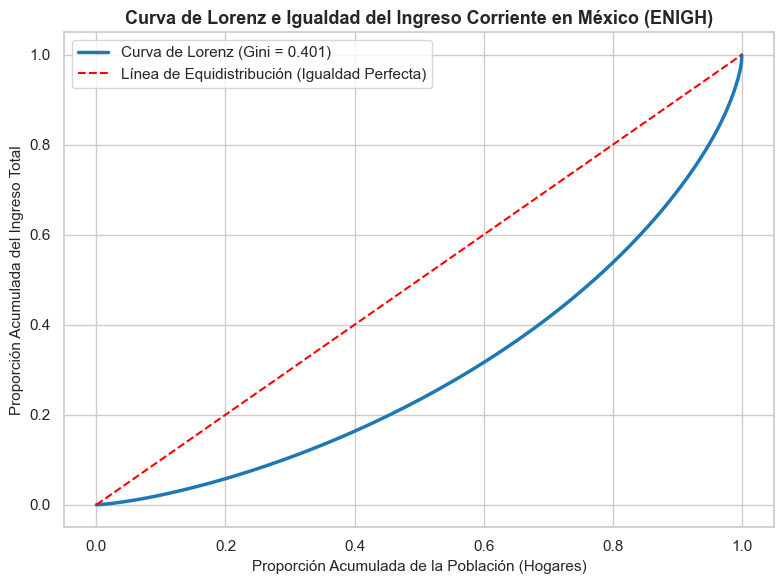

In [16]:

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Curva de Lorenz
plt.plot(p, l, color='#1f77b4', linewidth=2.5,
         label=f'Curva de Lorenz (Gini = {gini_val:.3f})')

# Línea de igualdad perfecta (diagonal)
plt.plot([0, 1], [0, 1], color='red', linestyle='--',
         label='Línea de Equidistribución (Igualdad Perfecta)')

# Títulos y etiquetas
plt.title('Curva de Lorenz e Igualdad del Ingreso Corriente en México (ENIGH)',
          fontsize=13, fontweight='bold')
plt.xlabel('Proporción Acumulada de la Población (Hogares)', fontsize=11)
plt.ylabel('Proporción Acumulada del Ingreso Total', fontsize=11)

# Leyenda y estilo
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

# Guardar y mostrar
plt.savefig('curva_lorenz_enigh.png', dpi=300)
plt.show()


#### Estructura del Gasto por Decil (Ley de Engel)

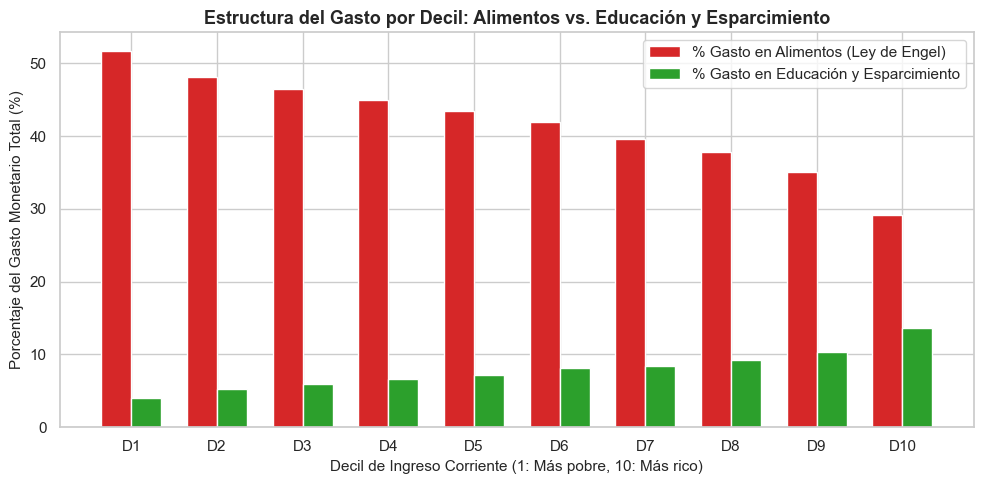

In [17]:

# Consulta SQL
query_deciles = """
WITH deciles_hogar AS (
    SELECT 
        ing_cor,
        gasto_mon,
        alimentos,
        educa_espa,
        factor,
        NTILE(10) OVER (ORDER BY ing_cor ASC) AS decil_ingreso
    FROM concentradohogar
)
SELECT 
    decil_ingreso,
    ROUND(SUM(alimentos * factor) / SUM(gasto_mon * factor) * 100, 2) AS pct_alimentos,
    ROUND(SUM(educa_espa * factor) / SUM(gasto_mon * factor) * 100, 2) AS pct_educa_esparcimiento
FROM deciles_hogar
GROUP BY decil_ingreso
ORDER BY decil_ingreso ASC;
"""

# Cargar resultados en DataFrame
df_deciles = pd.read_sql(query_deciles, con=engine)

# Gráfico comparativo
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

x = np.arange(len(df_deciles['decil_ingreso']))
width = 0.35

plt.bar(x - width/2, df_deciles['pct_alimentos'], width,
        label='% Gasto en Alimentos (Ley de Engel)', color='#d62728')
plt.bar(x + width/2, df_deciles['pct_educa_esparcimiento'], width,
        label='% Gasto en Educación y Esparcimiento', color='#2ca02c')

plt.xlabel('Decil de Ingreso Corriente (1: Más pobre, 10: Más rico)', fontsize=11)
plt.ylabel('Porcentaje del Gasto Monetario Total (%)', fontsize=11)
plt.title('Estructura del Gasto por Decil: Alimentos vs. Educación y Esparcimiento',
          fontsize=13, fontweight='bold')

plt.xticks(x, [f'D{i}' for i in df_deciles['decil_ingreso']])
plt.legend(loc='upper right')
plt.tight_layout()

plt.savefig('ley_engel_deciles.png', dpi=300)
plt.show()


#### Comparativa Jalisco vs. Resto de México

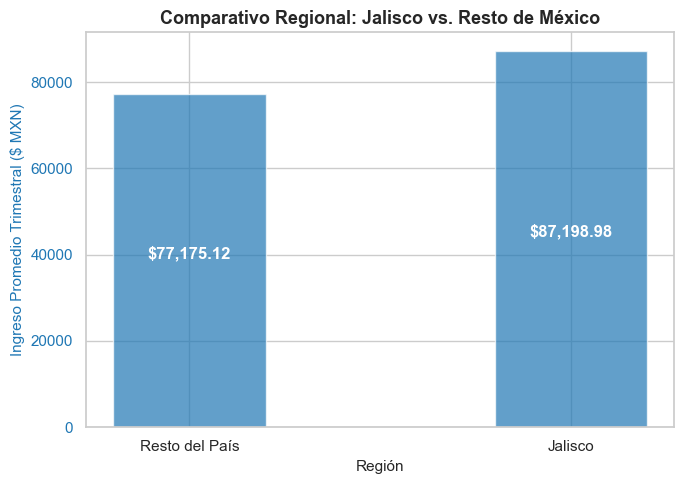

In [18]:

query_jalisco = """
SELECT 
    CASE 
        WHEN FLOOR(ubica_geo / 1000) = 14 THEN 'Jalisco'
        ELSE 'Resto del País' 
    END AS region,
    ROUND(SUM(ing_cor * factor) / SUM(factor), 2) AS ingreso_promedio_trimestral,
    ROUND(SUM(alimentos * factor) / SUM(gasto_mon * factor) * 100, 2) AS pct_gasto_alimentos
FROM concentradohogar
GROUP BY region;
"""

df_jalisco = pd.read_sql(query_jalisco, con=engine)

fig, ax1 = plt.subplots(figsize=(7, 5))

color = '#1f77b4'
ax1.set_xlabel('Región', fontsize=11)
ax1.set_ylabel('Ingreso Promedio Trimestral ($ MXN)', color=color, fontsize=11)
bars = ax1.bar(df_jalisco['region'], df_jalisco['ingreso_promedio_trimestral'], color=color, alpha=0.7, width=0.4)
ax1.tick_params(axis='y', labelcolor=color)

# Anotaciones de valor en las barras
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval/2, f"${yval:,.2f}", ha='center', va='bottom', color='white', fontweight='bold')

plt.title('Comparativo Regional: Jalisco vs. Resto de México', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparativo_jalisco.png', dpi=300)
plt.show()

